In [ ]:
import json

import numpy as np
from scipy.optimize import curve_fit

from func.model import Villain_fit
import matplotlib.pyplot as plt

In [55]:
N = 2
L = 9
BC = 'OBC'
pad = 5
conn_type = 'z'

beta = 1.5
alpha = 0.0
fit_times = 1000
bins = 60

data_file = f'data/data_N{N}_L{L}_{BC}_pad{pad}/data_N{N}_L{L}_{BC}_pad{pad}_beta{beta}_alpha{alpha}_num{fit_times}x{bins}_test.npz'
fit_result_file = f'results/a_dist_fit_{BC}_pad{pad}/N{N}_L{L}_{conn_type}/a_dist_fit_{BC}_pad{pad}_N{N}_L{L}_{conn_type}_beta{beta}_alpha{alpha}.json'

# Load data
data = np.load(data_file)
# Load result
with open(fit_result_file, 'r') as f:
    temp = json.load(f)
    fit_result = temp['villain_fit']

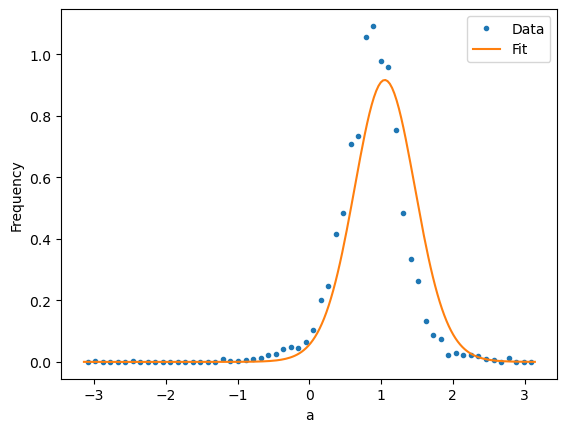

In [71]:
ind = np.random.randint(0, fit_times)
a_list = data[f'a{conn_type}'][ind]
phi_list = data[f'phi'][ind]
freq = data[f'freq{conn_type}'][ind*bins:(ind+1)*bins]

temp = np.linspace(-np.pi, np.pi, bins+1)
a0 = (temp[:-1] + temp[1:]) / 2
a0_fit = np.linspace(-np.pi, np.pi, 200)

beta_fit = fit_result['beta_fit']
alpha_fit = fit_result['alpha_fit']
fit_freq = [Villain_dist_norm(a, beta_fit, alpha_fit, np.hstack([a_list, phi_list])) for a in a0_fit]

plt.plot(a0, freq, '.', label='Data')
plt.plot(a0_fit, fit_freq, '-', label='Fit')
plt.xlabel('a')
plt.ylabel('Frequency')
plt.legend()
plt.show()